../data/archive/FaceForensics++_C23/crops/DeepFakeDetection\01_02__meeting_serious__YVGY8LOK\0_0.png
총 랜드마크 개수: 120
랜드마크 0: x=78, y=103
랜드마크 1: x=81, y=81
랜드마크 2: x=80, y=47
랜드마크 3: x=77, y=107
랜드마크 4: x=76, y=113
랜드마크 5: x=74, y=89
랜드마크 6: x=46, y=62
랜드마크 7: x=56, y=47
랜드마크 8: x=55, y=131
랜드마크 9: x=52, y=82
랜드마크 10: x=58, y=104
랜드마크 11: x=76, y=86
랜드마크 12: x=62, y=85
랜드마크 13: x=46, y=38
랜드마크 14: x=61, y=50
랜드마크 15: x=70, y=89
랜드마크 16: x=61, y=87
랜드마크 17: x=32, y=33
랜드마크 18: x=71, y=104
랜드마크 19: x=52, y=107
랜드마크 20: x=61, y=107
랜드마크 21: x=69, y=115
랜드마크 22: x=61, y=107
랜드마크 23: x=54, y=100
랜드마크 24: x=56, y=108
랜드마크 25: x=57, y=73
랜드마크 26: x=41, y=28
랜드마크 27: x=67, y=27
랜드마크 28: x=64, y=60
랜드마크 29: x=23, y=69
랜드마크 30: x=56, y=69
랜드마크 31: x=31, y=51
랜드마크 32: x=67, y=64
랜드마크 33: x=15, y=96
랜드마크 34: x=31, y=127
랜드마크 35: x=54, y=137
랜드마크 36: x=47, y=59
랜드마크 37: x=63, y=144
랜드마크 38: x=73, y=145
랜드마크 39: x=27, y=50
랜드마크 40: x=46, y=53
랜드마크 41: x=78, y=96
랜드마크 42: x=80, y=54
랜드마크 43: x=24, y=1

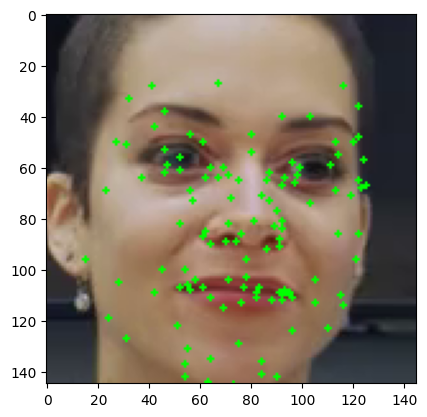

In [5]:
import cv2
# 최신 버전에서는 이렇게 불러옵니다
from mediapipe.python.solutions import face_mesh
from mediapipe.python.solutions import drawing_utils as mp_drawing
import os
import matplotlib.pyplot as plt

# 이미지 불러오기
DFD_PATH = "../data/archive/FaceForensics++_C23/crops/DeepFakeDetection"
image_folders = os.listdir(DFD_PATH)
sample_folder = image_folders[0]
sample_folder_path = os.path.join(DFD_PATH, sample_folder)
sample_file = os.listdir(sample_folder_path)[0]
image_path = os.path.join(sample_folder_path, sample_file)
print(image_path)
image = cv2.imread(image_path)
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# FaceMesh 객체 생성
with face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=0.5) as mesh:

    results = mesh.process(rgb_image)

    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            print("총 랜드마크 개수:", len(face_landmarks.landmark[::4]))
            for idx, lm in enumerate(face_landmarks.landmark[::4]):
                x = int(lm.x * image.shape[1])
                y = int(lm.y * image.shape[0])
                print(f"랜드마크 {idx}: x={x}, y={y}")

                cv2.circle(image, (x, y), 1, (0, 255, 0), -1)

final_image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(final_image_rgb)
plt.show()

In [1]:
import numpy as np

print(np.__version__)

np.array([1,2,3,4])

1.26.4


array([1, 2, 3, 4])

In [8]:
from albumentations import Compose, Resize
help(Resize)

Help on class Resize in module albumentations.augmentations.transforms:

class Resize(albumentations.core.transforms_interface.DualTransform)
 |  Resize(height, width, interpolation=1, always_apply=False, p=1)
 |  
 |  Resize the input to the given height and width.
 |  
 |  Args:
 |      height (int): desired height of the output.
 |      width (int): desired width of the output.
 |      interpolation (OpenCV flag): flag that is used to specify the interpolation algorithm. Should be one of:
 |          cv2.INTER_NEAREST, cv2.INTER_LINEAR, cv2.INTER_CUBIC, cv2.INTER_AREA, cv2.INTER_LANCZOS4.
 |          Default: cv2.INTER_LINEAR.
 |      p (float): probability of applying the transform. Default: 1.
 |  
 |  Targets:
 |      image, mask, bboxes, keypoints
 |  
 |  Image types:
 |      uint8, float32
 |  
 |  Method resolution order:
 |      Resize
 |      albumentations.core.transforms_interface.DualTransform
 |      albumentations.core.transforms_interface.BasicTransform
 |      builti